In [31]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
import sys
from pathlib import Path

current = Path.cwd()
project_root = current.parent.parent
sys.path.append(str(project_root))

from utils import add_project_root_to_sys_path
add_project_root_to_sys_path()

In [33]:
from data.linear import LinearTaskGenerator, TaskGenerator
from models.linear_attention import SingleLayerLSA
from experiments.single_layer.train import train_ICL_model
from experiments.single_layer.test import compare_SignelLSA_matrices
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim

### Implicit weight extraction

In [34]:
NX = 10
NY = 1

N = 10  # Important increase
W_STD = 1.0
X_RANGE = (-1, 1)

N_STEPS = 1000
BATCH_SIZE = 2048
LR = 0.001

ETA_VALUES = np.logspace(-3, 2, 100)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
generator = LinearTaskGenerator(nx=NX, ny=NY, x_range=X_RANGE, w_std=W_STD)
model = SingleLayerLSA(nx=NX, ny=NY)
optimizer = optim.AdamW(model.parameters(), lr=LR)
device

'cpu'

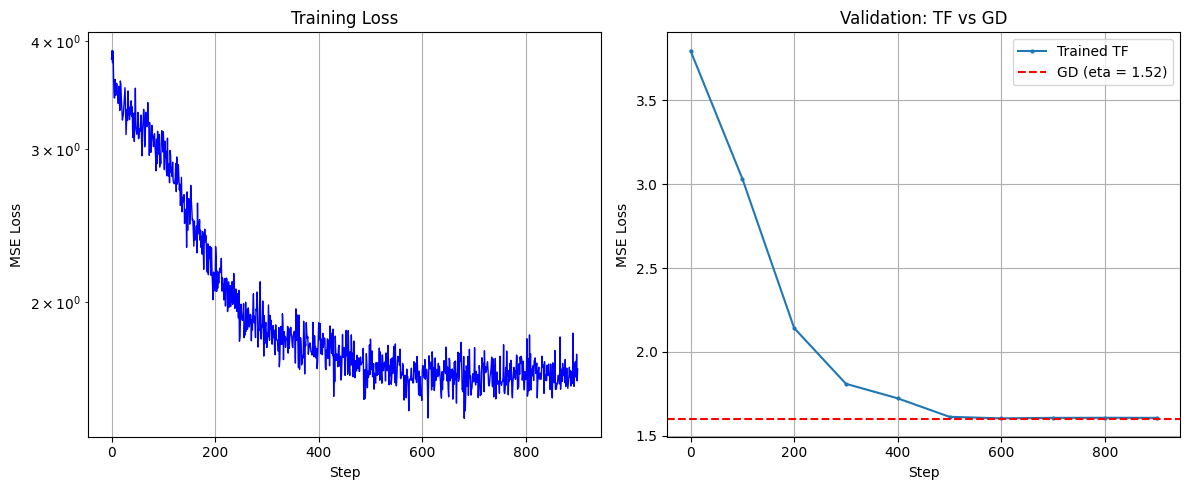

Training: 100%|██████████| 1000/1000 [00:57<00:00, 17.31it/s, gd_val=1.6011, tf_val=1.6068, train_loss=1.67]


In [35]:
model, losses, tf_val, gd_val, best_eta = train_ICL_model(
    model=model,
    task_generator=generator,
    optimizer=optimizer,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    lr=LR,
    N=N,
    device=device,
    verbose=True,
    test_interval=100,
    val_tasks=1000,
    eta_values=ETA_VALUES
)

In [49]:
from sklearn.linear_model import LinearRegression

def weight_extraction(model,
                      device = device,
                      generator: TaskGenerator = generator,
                      samples_num: int = 1000,
                      N: int = N,
                      refresh_generator: bool = False,
                      verbose: bool = True
                      ):
    """
    TODO

    Args:
        model: модель, реализующая методы forward и predict
        task_generator: Генератор задач с методом .generate_task(N).
        N: Количество обучающих примеров в контексте.
        NX, NY: Размерности задачи
        verbose: Если True, показывает прогресс-бар и графики.

    Returns:
        Matrix: Наилучше приближающая модель матрица
        R^2: R^2-score матрицы

    targets = np.array(targets)
    """
    NX: int = generator.nx
    NY: int = generator.ny
    tokens = []
    assert samples_num > 20 * (NX + NY), "Количество сэмплов должно быть сильно больше размерности векторов"

    if refresh_generator:
        generator.generate_teacher()

    for _ in range(samples_num):
        x, _ = generator.generate_task(N=N, new_params=False)
        if len(tokens) != 0:
            tokens.append(tokens[-1].copy())
            tokens[-1][N] = x[N]
            continue
        tokens.append(x)

    tokens = torch.FloatTensor(np.array(tokens)).to(device)
    tokens_ends = tokens.detach().numpy()[:, N, :NX]

    model.eval()
    pred = model.predict(tokens).detach().numpy()

    W_true = generator.teacher_params
    lin_reg = LinearRegression(fit_intercept=False).fit(tokens_ends, pred)

    if verbose:
        print("||W_true - W_extr||_2 =", np.linalg.norm(W_true - lin_reg.coef_))
        print("R^2 =", lin_reg.score(tokens_ends, pred))
    return lin_reg.coef_, lin_reg.score(tokens_ends, pred)

In [50]:
print(weight_extraction(model, generator=generator, refresh_generator=True)[0])
print(generator.teacher_params)

||W_true - W_extr||_2 = 2.4207909539097647
R^2 = 0.9999991655349731
[[ 1.5713989  -1.0126591   0.34207544  1.3707314   0.5259789  -1.6368065
   0.6187896   0.03031349  0.5664277  -0.19186202]]
[[ 2.27782671 -0.76563177  0.82374634  0.41025987 -0.32138507 -1.66513726
   1.85102428  1.1302022  -0.08979439  0.32586423]]


In [54]:
from data.weights_extraction.weights_extraction import weight_extraction as we
print(we(model, device, generator, refresh_generator=True)[0])
print(generator.teacher_params)

||W_true - W_extr||_2 = 8.863088191367984
R^2 = 0.9999999403953552
[[-1.0519553  -0.3122139  -0.08712575 -2.4443207   2.694726    1.8872365
   7.12516    -4.056731    6.438581   -3.7433026 ]]
[[-0.26836844 -0.37667662 -0.70259075 -0.26097618  1.05026253 -0.56484028
   2.17575377 -1.20941024  1.48496136 -1.11057982]]


## Notes

1. Замораживаем модель

2. Генерируем X (сильно больще из размерности)
 ? как генерировать ? 
 ! генерируем как X на обучении и на тестах !
 
3. Фиксируем контекст 
 ? какой выбрать контекст ? : Если не фиксированная длина, то нетривиальный выбор размераx
 
4. Получаем предсказания модели Y^ (теперь |X| = |Y^|)

5. Обучаем матрицу размера  d_x * d_y оптимизируя некоторую метрику (наверное, MSE) для предсказания Y^ по X.

6. Считаем статистику верхней линейной регрессии, насколько она валидна (statsmodels). 

Псевдокод:
```
Matrix (SampleSIZE, d_x, d_y, TrueTheta, GenerateX, Model, Noise) 
{
    X = GenerateX(SampleSIZE, d_x)
    Y = Noise(X^T @ TrueTheta)
    
    PointSIZE = 50 * (d_x + d_y)  # чтобы было гарантировано больше чем размерность
    
    X' = GenerateX(PointSIZE, d_x)
    Y'_i = Model(
        Context: (X, Y) + {X'_i, 0},
    )  # получаем пары (X' Y') те, что предсказал трансформер
    
    EstTheta = LinReg(X', Y')  # неявная матрица
    
    return {EstTheta, check(X', Y', EstTheta)}   # выводим матрицу и R^2
}
(EstTheta, Coef.determ)
```